# MLB Pitcher Injury Risk Prediction — Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv("final_dataset.csv")
df['game_date'] = pd.to_datetime(df['game_date'])
df = df.sort_values(['pitcher', 'game_date']).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Pitchers: {df['pitcher'].nunique()}")
print(f"Seasons: {sorted(df['season'].unique())}")
print(f"Injury-positive rate: {df['injured_next_21d'].mean():.2%}")

Dataset shape: (54124, 23)
Pitchers: 356
Seasons: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Injury-positive rate: 3.17%


## 1. Data Quality Check

In [2]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print(f"\nTotal rows: {len(df)}")

Columns with missing values:
avg_spin_rate    347
spin_drop        347
avg_extension    325
dtype: int64

Total rows: 54124


### Imputation

`avg_spin_rate` and `avg_extension` have missing values due to Statcast tracking gaps. We impute using each pitcher's own season-level median to preserve within-pitcher consistency. `spin_drop` is then recomputed.

In [3]:
# Impute avg_spin_rate and avg_extension with pitcher-level median
df['avg_spin_rate'] = df.groupby('pitcher')['avg_spin_rate'].transform(
    lambda x: x.fillna(x.median())
)
df['avg_extension'] = df.groupby('pitcher')['avg_extension'].transform(
    lambda x: x.fillna(x.median())
)

# Recompute spin_drop after imputation
df['spin_drop'] = df.groupby('pitcher')['avg_spin_rate'].transform('mean') - df['avg_spin_rate']

print(f"Remaining missing values: {df.isnull().sum().sum()}")

Remaining missing values: 0


## 2. Class Imbalance

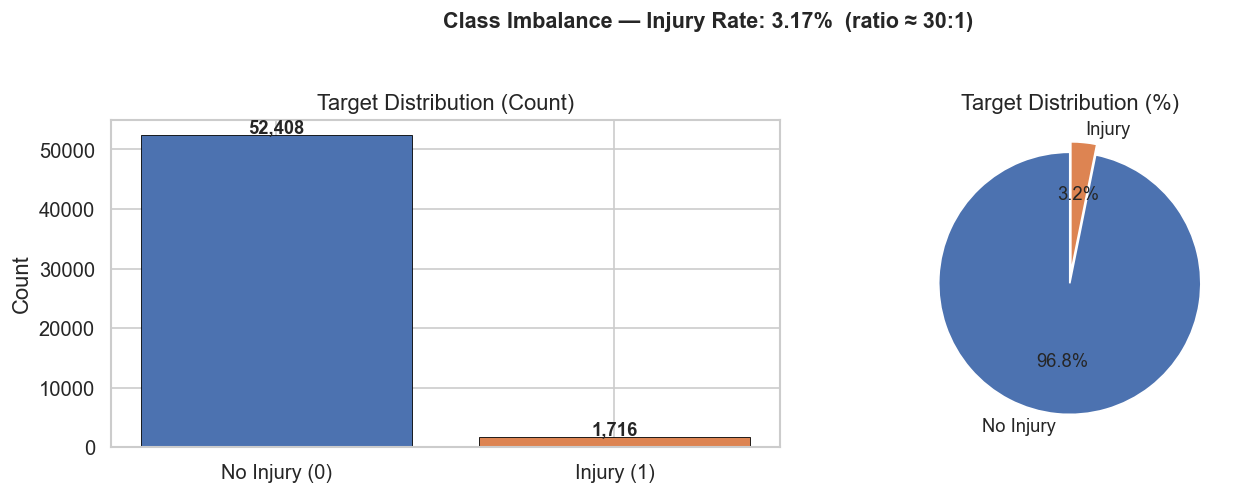

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart with counts
counts = df['injured_next_21d'].value_counts().sort_index()
bars = axes[0].bar(['No Injury (0)', 'Injury (1)'], counts.values, 
                     color=['#4c72b0', '#dd8452'], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300, 
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution (Count)')

# Percentage pie
axes[1].pie(counts.values, labels=['No Injury', 'Injury'], autopct='%1.1f%%',
            colors=['#4c72b0', '#dd8452'], startangle=90, 
            explode=[0, 0.08], textprops={'fontsize': 11})
axes[1].set_title('Target Distribution (%)')

plt.suptitle(f'Class Imbalance — Injury Rate: {df["injured_next_21d"].mean():.2%}  (ratio ≈ {int(counts[0]/counts[1])}:1)', 
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## 3. Injury Rate by Season

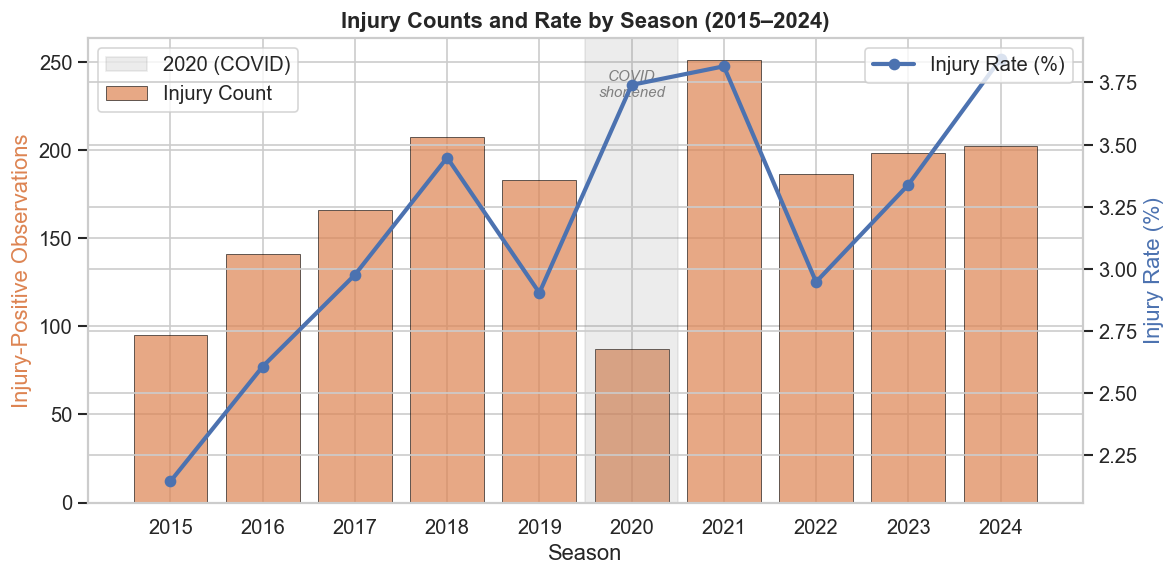

In [5]:
season_stats = df.groupby('season').agg(
    total_starts=('injured_next_21d', 'count'),
    injuries=('injured_next_21d', 'sum'),
    injury_rate=('injured_next_21d', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar for injury count
bars = ax1.bar(season_stats['season'], season_stats['injuries'], 
               color='#dd8452', alpha=0.7, label='Injury Count', edgecolor='black', linewidth=0.5)
ax1.set_ylabel('Injury-Positive Observations', color='#dd8452')
ax1.set_xlabel('Season')

# Line for injury rate on secondary axis
ax2 = ax1.twinx()
ax2.plot(season_stats['season'], season_stats['injury_rate']*100, 
         color='#4c72b0', marker='o', linewidth=2.5, label='Injury Rate (%)')
ax2.set_ylabel('Injury Rate (%)', color='#4c72b0')

# Highlight COVID 2020 season
ax1.axvspan(2019.5, 2020.5, color='gray', alpha=0.15, label='2020 (COVID)')
ax1.annotate('COVID\nshortened', xy=(2020, season_stats[season_stats['season']==2020]['injuries'].values[0]),
             xytext=(2020, 230), fontsize=9, ha='center', style='italic', color='gray')

ax1.set_xticks(season_stats['season'])
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.title('Injury Counts and Rate by Season (2015–2024)', fontweight='bold')
plt.tight_layout()
plt.show()

The 2020 COVID-shortened season has fewer total observations but a *higher* injury rate (3.7%), consistent with the hypothesis that disrupted training schedules elevated risk. The overall trend from 2015 to 2024 shows a gradual increase in injury rates.

## 4. Data Cleaning — Outliers

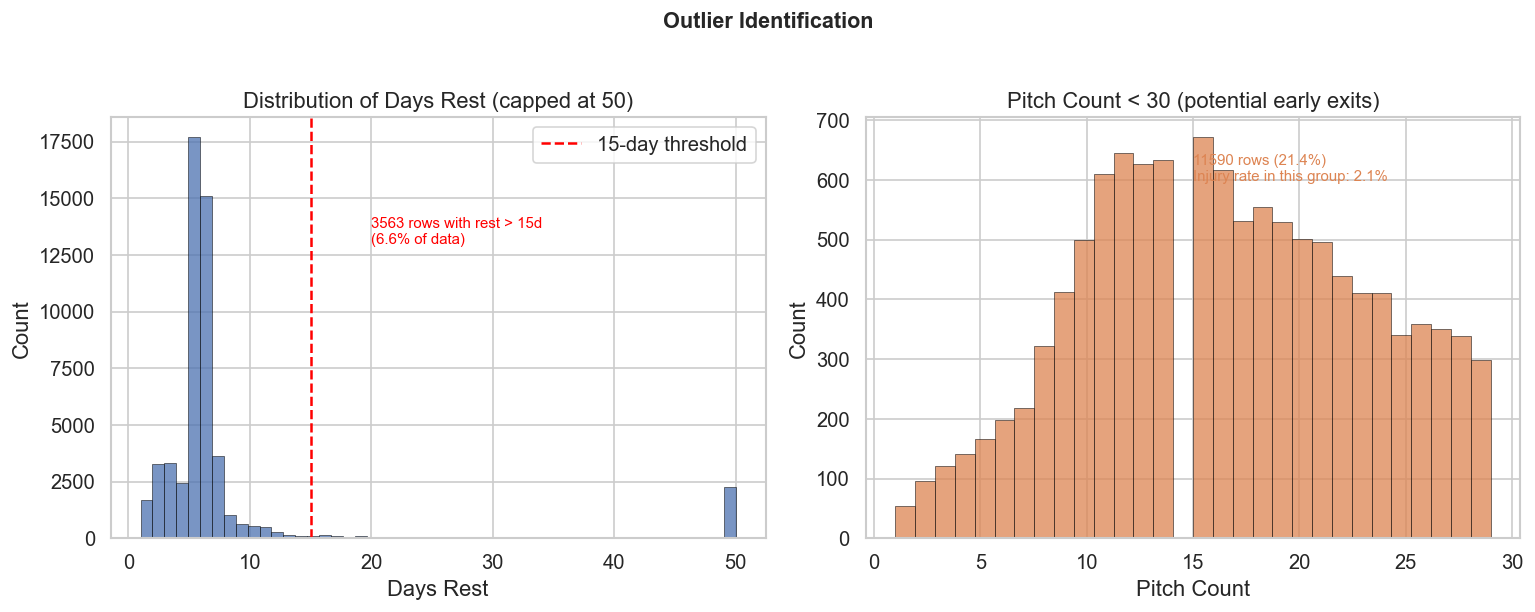

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# days_rest distribution (capped for visualization)
ax = axes[0]
rest_cap = df['days_rest'].clip(upper=50)
sns.histplot(rest_cap, bins=50, ax=ax, color='#4c72b0', edgecolor='black', linewidth=0.3)
ax.axvline(x=15, color='red', linestyle='--', linewidth=1.5, label='15-day threshold')
ax.set_title('Distribution of Days Rest (capped at 50)')
ax.set_xlabel('Days Rest')
ax.legend()
ax.annotate(f'{(df["days_rest"]>15).sum()} rows with rest > 15d\n({(df["days_rest"]>15).mean():.1%} of data)',
            xy=(20, ax.get_ylim()[1]*0.7), fontsize=9, color='red')

# low pitch count
ax = axes[1]
low_pc = df[df['pitch_count'] < 30]
sns.histplot(low_pc['pitch_count'], bins=30, ax=ax, color='#dd8452', edgecolor='black', linewidth=0.3)
ax.set_title('Pitch Count < 30 (potential early exits)')
ax.set_xlabel('Pitch Count')
ax.annotate(f'{len(low_pc)} rows ({len(low_pc)/len(df):.1%})\nInjury rate in this group: {low_pc["injured_next_21d"].mean():.1%}',
            xy=(0.5, 0.85), xycoords='axes fraction', fontsize=9, color='#dd8452')

plt.suptitle('Outlier Identification', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Observations with very low pitch counts (< 10) likely reflect early exits due to injury and may corrupt velocity-based features. Extremely high rest days (> 500) are rare and represent cross-season gaps rather than meaningful rest signals. Both will be addressed in preprocessing before modeling.

## 5. Feature Distributions by Injury Outcome

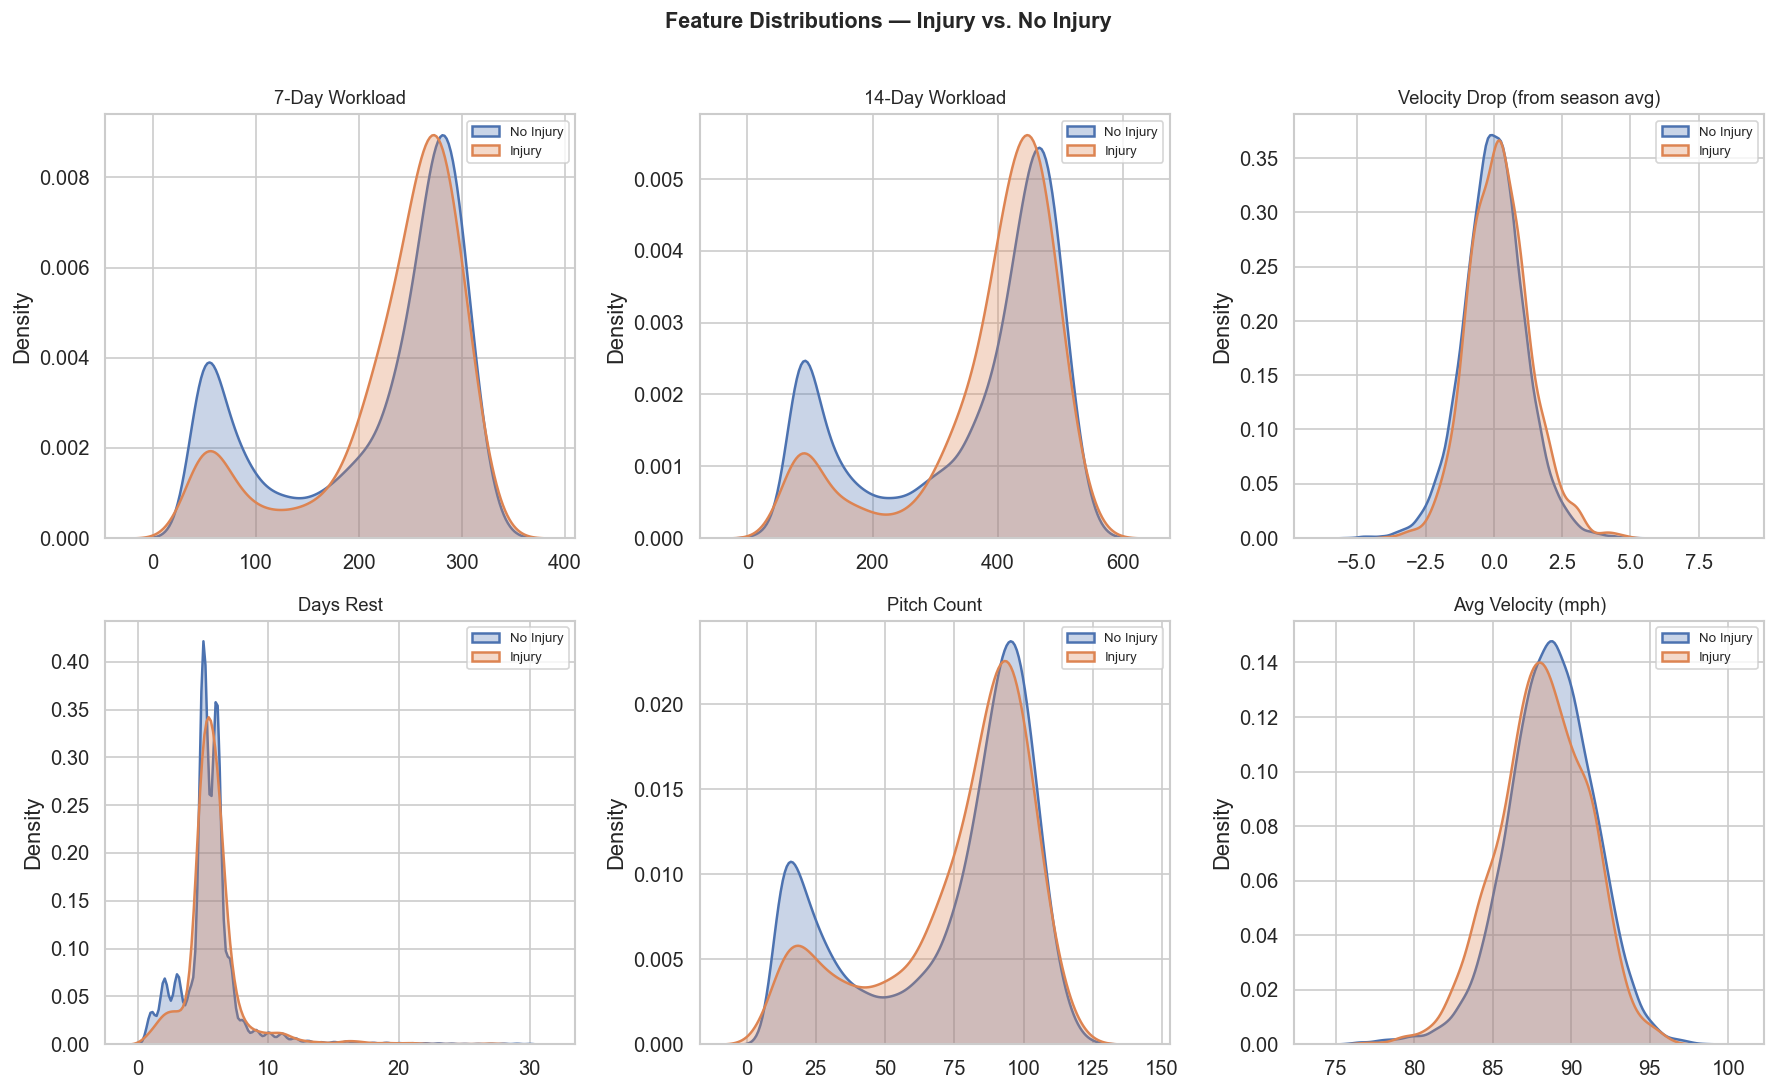

In [7]:
# Filter out extreme outliers for cleaner visualization
df_clean = df[(df['days_rest'] <= 30) & (df['pitch_count'] >= 10)].copy()

features = ['workload_7d', 'workload_14d', 'vel_drop_from_season_avg', 'days_rest', 'pitch_count', 'avg_velocity']
labels = {'workload_7d': '7-Day Workload', 'workload_14d': '14-Day Workload', 
          'vel_drop_from_season_avg': 'Velocity Drop (from season avg)', 
          'days_rest': 'Days Rest', 'pitch_count': 'Pitch Count', 'avg_velocity': 'Avg Velocity (mph)'}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    for label, color in [(0, '#4c72b0'), (1, '#dd8452')]:
        subset = df_clean[df_clean['injured_next_21d'] == label][feat].dropna()
        sns.kdeplot(subset, ax=ax, color=color, fill=True, alpha=0.3, linewidth=1.5,
                    label='No Injury' if label == 0 else 'Injury')
    ax.set_title(labels[feat], fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions — Injury vs. No Injury', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Key observations from the KDE plots:
- **Workload (7d & 14d)**: The injured group shows a subtle shift toward higher cumulative workload, consistent with fatigue-driven risk.
- **Velocity Drop**: Injured pitchers show a slightly wider spread, suggesting more erratic velocity patterns leading up to injury.
- **Days Rest & Pitch Count**: Distributions largely overlap, indicating these alone are not strong discriminators but may interact with other features.
- **Avg Velocity**: Nearly identical distributions — raw velocity level is not predictive; *change* in velocity matters more.

## 6. Feature Correlations

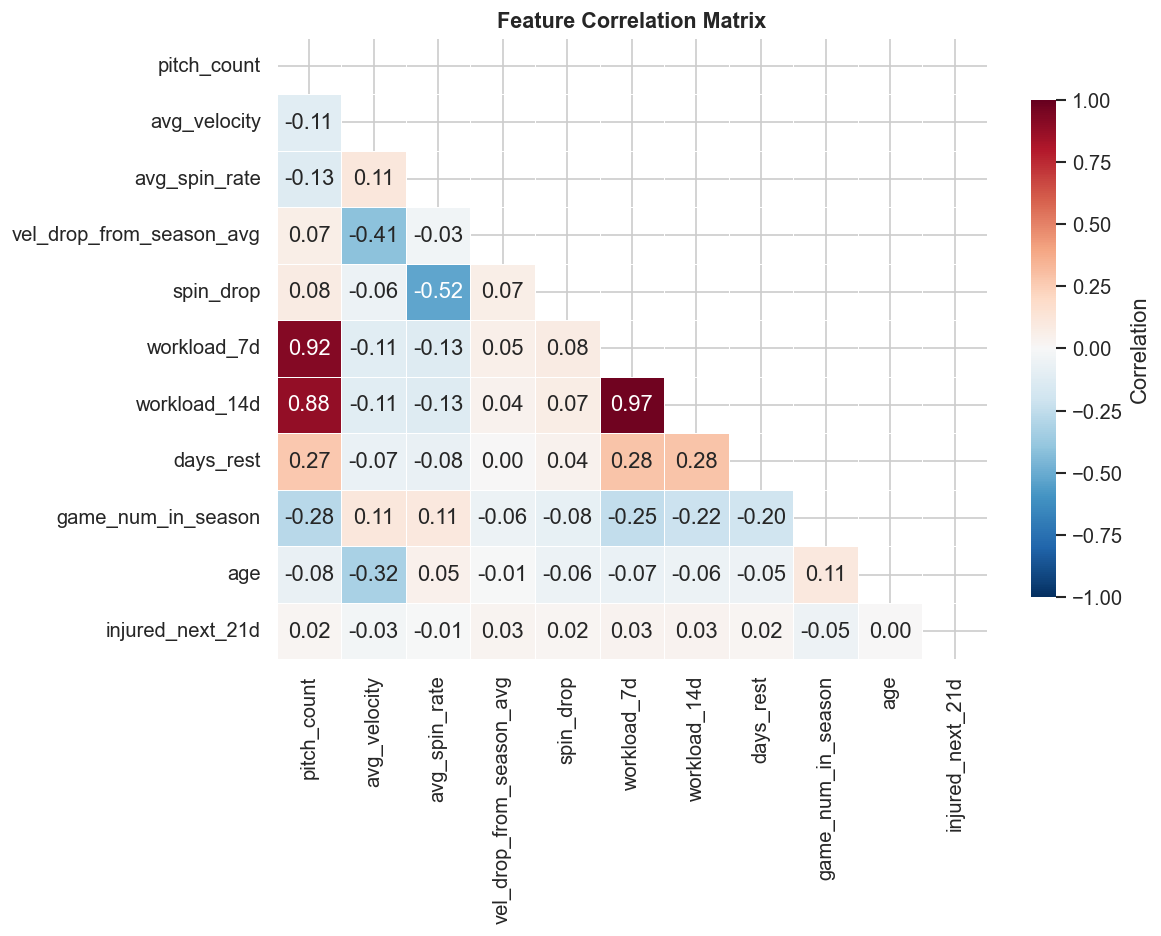

In [8]:
corr_cols = ['pitch_count', 'avg_velocity', 'avg_spin_rate', 'vel_drop_from_season_avg', 
             'spin_drop', 'workload_7d', 'workload_14d', 'days_rest', 
             'game_num_in_season', 'age', 'injured_next_21d']

corr_matrix = df_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, 
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

Notable correlations:
- `workload_7d` and `workload_14d` are highly correlated — we may consider dropping one or using only the 14-day window to avoid multicollinearity.
- `vel_drop_from_season_avg` and `spin_drop` show weak correlation with the target, but their interaction effects may be more informative.
- `age` has negligible linear correlation with injury — consistent with the idea that biomechanical fatigue signals matter more than age alone.

## 7. Interaction Effects — Workload × Velocity Drop

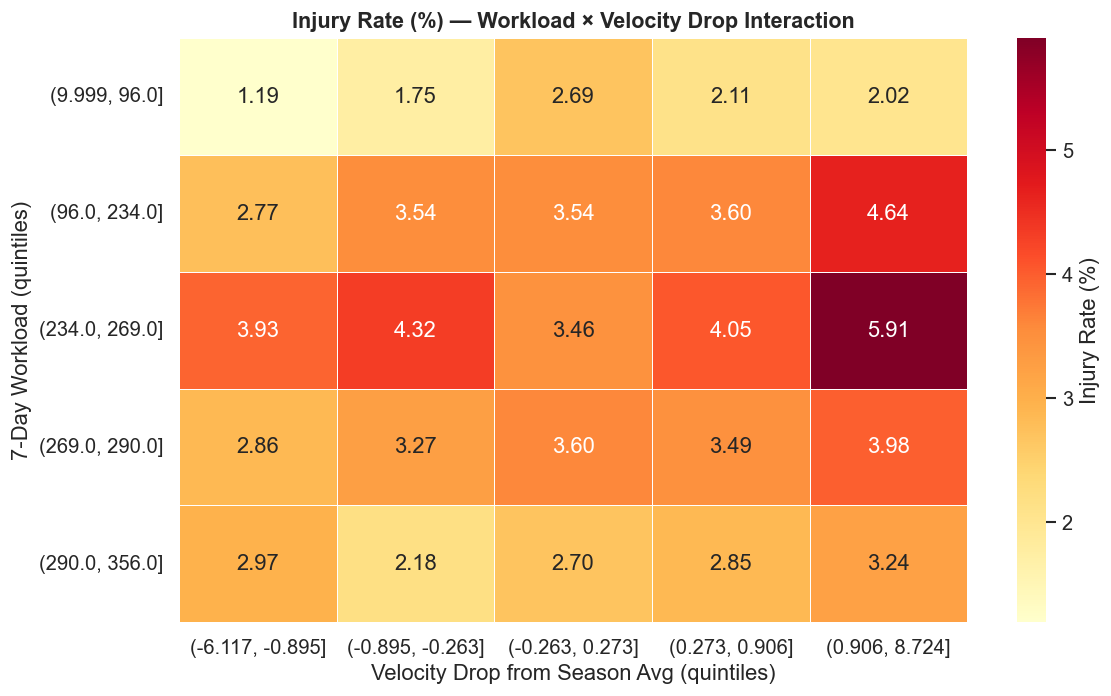

In [9]:
df_model = df_clean.copy()

# Bin workload and velocity drop into quintiles
df_model['workload_bin'] = pd.qcut(df_model['workload_7d'], q=5, duplicates='drop')
df_model['vel_drop_bin'] = pd.qcut(df_model['vel_drop_from_season_avg'], q=5, duplicates='drop')

pivot = df_model.pivot_table(
    values='injured_next_21d',
    index='workload_bin',
    columns='vel_drop_bin',
    aggfunc='mean'
) * 100  # convert to percentage

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Injury Rate (%)'})
ax.set_xlabel('Velocity Drop from Season Avg (quintiles)')
ax.set_ylabel('7-Day Workload (quintiles)')
ax.set_title('Injury Rate (%) — Workload × Velocity Drop Interaction', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

The heatmap reveals that injury risk tends to be highest in cells combining high workload with extreme velocity drop. This interaction effect supports engineering a combined workload–velocity feature and motivates tree-based models (Random Forest, XGBoost) that can capture such non-linear interactions natively.

## 8. Marginal Injury Rates by Feature Bins

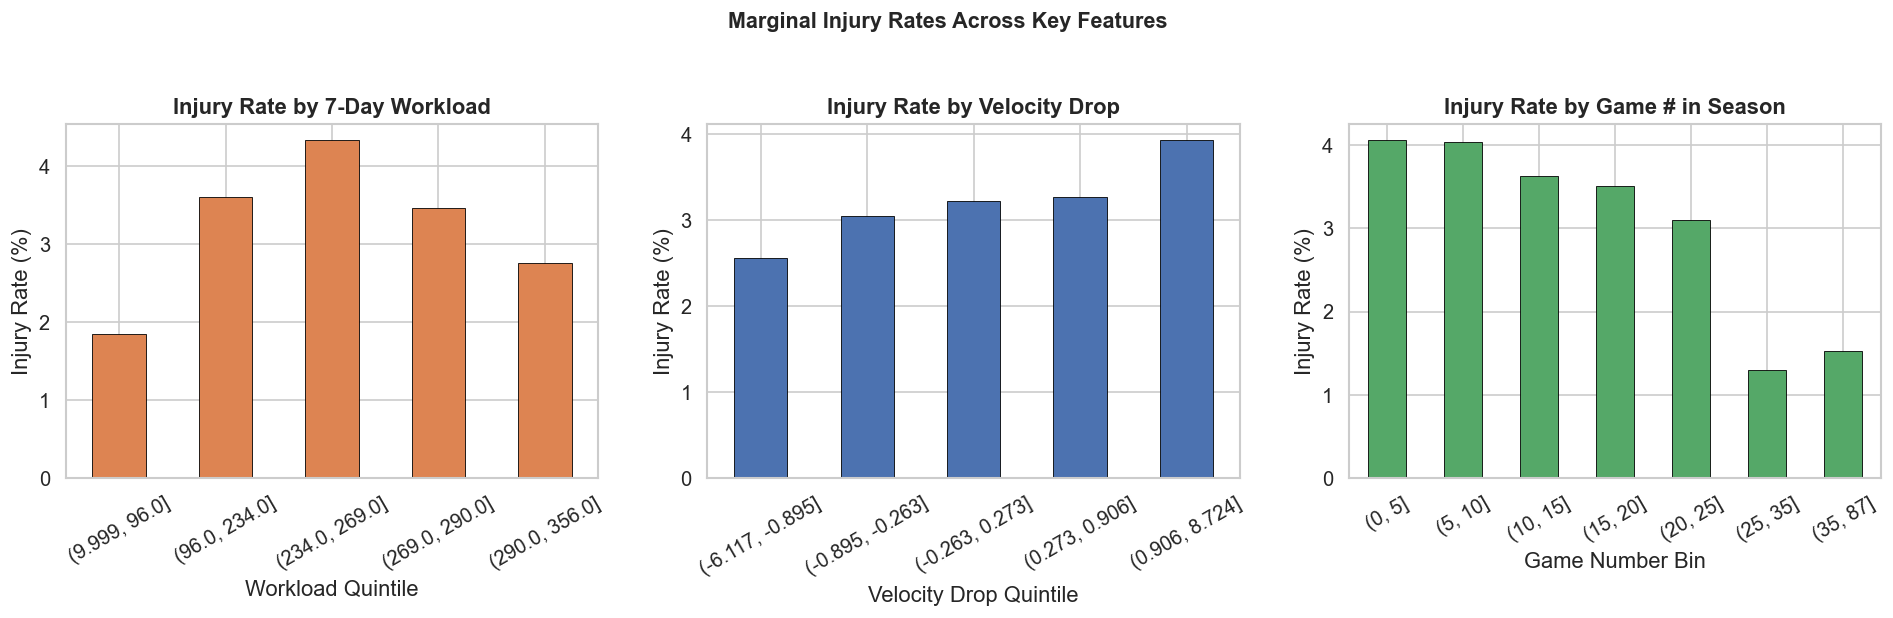

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Workload 7d bins
ax = axes[0]
bins_wl = pd.qcut(df_clean['workload_7d'], q=5, duplicates='drop')
rates_wl = df_clean.groupby(bins_wl)['injured_next_21d'].mean() * 100
rates_wl.plot(kind='bar', ax=ax, color='#dd8452', edgecolor='black', linewidth=0.5)
ax.set_title('Injury Rate by 7-Day Workload', fontweight='bold')
ax.set_ylabel('Injury Rate (%)')
ax.set_xlabel('Workload Quintile')
ax.tick_params(axis='x', rotation=30)

# Velocity drop bins
ax = axes[1]
bins_vd = pd.qcut(df_clean['vel_drop_from_season_avg'], q=5, duplicates='drop')
rates_vd = df_clean.groupby(bins_vd)['injured_next_21d'].mean() * 100
rates_vd.plot(kind='bar', ax=ax, color='#4c72b0', edgecolor='black', linewidth=0.5)
ax.set_title('Injury Rate by Velocity Drop', fontweight='bold')
ax.set_ylabel('Injury Rate (%)')
ax.set_xlabel('Velocity Drop Quintile')
ax.tick_params(axis='x', rotation=30)

# Game number in season
ax = axes[2]
bins_gn = pd.cut(df_clean['game_num_in_season'], bins=[0, 5, 10, 15, 20, 25, 35, 87])
rates_gn = df_clean.groupby(bins_gn)['injured_next_21d'].mean() * 100
rates_gn.plot(kind='bar', ax=ax, color='#55a868', edgecolor='black', linewidth=0.5)
ax.set_title('Injury Rate by Game # in Season', fontweight='bold')
ax.set_ylabel('Injury Rate (%)')
ax.set_xlabel('Game Number Bin')
ax.tick_params(axis='x', rotation=30)

plt.suptitle('Marginal Injury Rates Across Key Features', fontweight='bold', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

These bar charts show how injury rates vary across binned feature values:
- Higher 7-day workload bins trend toward higher injury rates, supporting cumulative fatigue as a risk factor.
- Velocity drop shows a non-monotonic pattern — both large negative and positive deviations may indicate risk.
- Injury rates tend to increase later in the season (higher game number), consistent with cumulative wear.

## 9. Pitcher-Level Velocity Timeline (Sample)

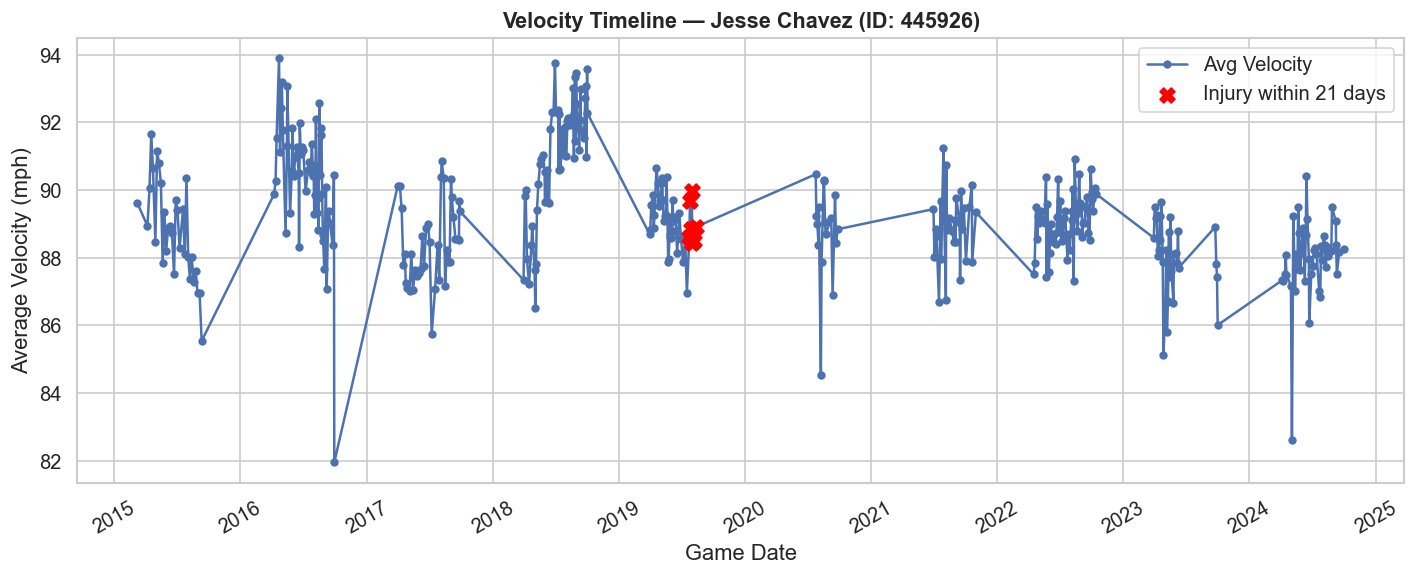

In [11]:
# Pick a pitcher with at least one injury and enough data
injured_pitchers = df_clean[df_clean['injured_next_21d'] == 1]['pitcher'].unique()
pitcher_counts = df_clean[df_clean['pitcher'].isin(injured_pitchers)].groupby('pitcher').size()
sample_pitcher = pitcher_counts[pitcher_counts >= 15].idxmax()

sample = df_clean[df_clean['pitcher'] == sample_pitcher].copy()
pitcher_name = sample['pitcher_name'].iloc[0]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sample['game_date'], sample['avg_velocity'], color='#4c72b0', marker='o', 
        markersize=4, linewidth=1.5, label='Avg Velocity')

# Mark injury windows
injury_games = sample[sample['injured_next_21d'] == 1]
ax.scatter(injury_games['game_date'], injury_games['avg_velocity'], 
           color='red', s=80, zorder=5, label='Injury within 21 days', marker='X')

ax.set_xlabel('Game Date')
ax.set_ylabel('Average Velocity (mph)')
ax.set_title(f'Velocity Timeline — {pitcher_name} (ID: {sample_pitcher})', fontweight='bold', fontsize=13)
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

This timeline illustrates how velocity can decay in the starts leading up to an injury event (red X markers). This is exactly the kind of within-season fatigue signal that our game-level approach is designed to capture, and that season-level models would miss entirely.

## 10. Workload vs. Velocity Drop (Downsampled Visualization)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


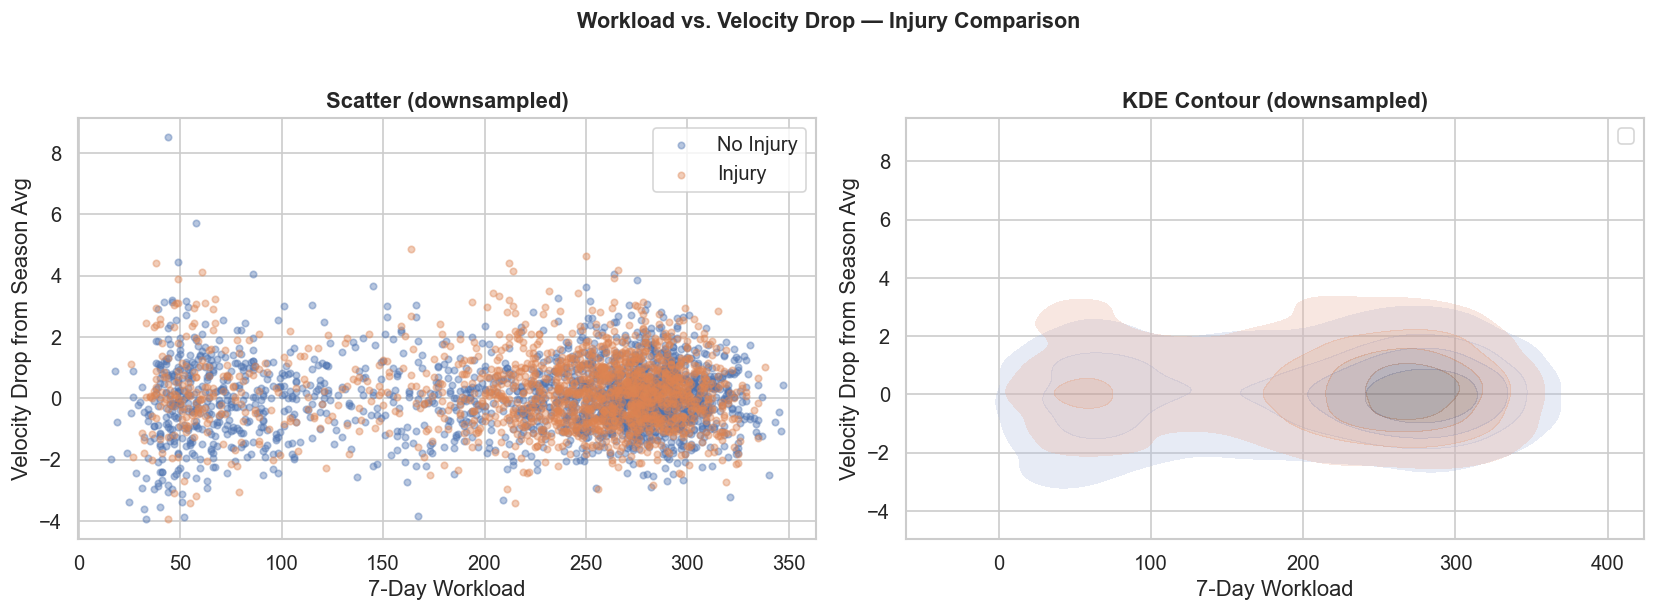

In [12]:
# Downsample majority class for visualization only
np.random.seed(42)
df_0 = df_clean[df_clean['injured_next_21d'] == 0].sample(n=2000)
df_1 = df_clean[df_clean['injured_next_21d'] == 1]
df_vis = pd.concat([df_0, df_1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
ax = axes[0]
for label, color, name in [(0, '#4c72b0', 'No Injury'), (1, '#dd8452', 'Injury')]:
    subset = df_vis[df_vis['injured_next_21d'] == label]
    ax.scatter(subset['workload_7d'], subset['vel_drop_from_season_avg'], 
               alpha=0.4, s=15, color=color, label=name)
ax.set_xlabel('7-Day Workload')
ax.set_ylabel('Velocity Drop from Season Avg')
ax.set_title('Scatter (downsampled)', fontweight='bold')
ax.legend()

# KDE contour
ax = axes[1]
for label, color, name in [(0, '#4c72b0', 'No Injury'), (1, '#dd8452', 'Injury')]:
    subset = df_vis[df_vis['injured_next_21d'] == label]
    sns.kdeplot(x=subset['workload_7d'], y=subset['vel_drop_from_season_avg'],
                ax=ax, color=color, fill=True, alpha=0.3, levels=5, label=name)
ax.set_xlabel('7-Day Workload')
ax.set_ylabel('Velocity Drop from Season Avg')
ax.set_title('KDE Contour (downsampled)', fontweight='bold')
ax.legend()

plt.suptitle('Workload vs. Velocity Drop — Injury Comparison', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The scatter and KDE plots (using a downsampled majority class for visibility) show substantial overlap between injured and non-injured groups. This is expected given the 3% base rate and confirms that no single pair of features creates clean separation — motivating the use of ensemble models that combine many weak signals.

## Summary of EDA Findings

**Key takeaways for modeling:**

1. **Severe class imbalance** (~3.2% injury rate, 30:1 ratio) demands SMOTE or class weighting, with evaluation via Precision-Recall AUC and F1 rather than accuracy.

2. **Workload features are the strongest signals** — 7-day and 14-day cumulative workload show the clearest marginal trends with injury rate. However, they are highly correlated with each other.

3. **Velocity drop matters in interaction** — while weakly correlated with injury on its own, velocity drop combined with high workload produces the highest risk cells in the interaction heatmap.

4. **Non-linear patterns** — the non-monotonic relationship between velocity drop and injury rate, plus the interaction effects, support tree-based models (Random Forest, XGBoost) over purely linear approaches.

5. **Data cleaning before modeling**: filter out pitch counts < 10 (early exits), cap or remove extreme rest day outliers (> 500 days), and consider the 2020 COVID season as a potential confounder.

6. **Feature selection considerations**: `workload_7d` and `workload_14d` multicollinearity should be addressed. `age` shows negligible predictive value in isolation but may interact with workload features.

